All samples are included.

Data used in the analysis:


,Sample,Series,Sintering time (h),Porosity (%),Broken
0,1-A,1,2.0,25.0,False
1,1-B,1,2.0,12.0,False
2,1-C,1,2.0,20.0,False
3,1-D,1,2.0,25.0,True
4,1-E,1,2.0,16.0,False
5,1-F,1,2.0,11.0,False
6,2-A,2,3.0,26.0,False
7,2-B,2,3.0,27.0,False
8,2-C,2,3.0,12.0,False
9,2-D,2,3.0,8.0,False



Statistical summary:


,N,Mean,Median,Standard_deviation,Q1,Q3,IQR,Minimum,Maximum
Sintering time (h),,,,,,,,,
2.0,12,23.67,25.0,7.41,19.00,29.25,10.25,11.0,33.0
2.5,8,24.38,24.0,2.62,22.75,25.50,2.75,21.0,29.0
3.0,10,20.60,21.5,6.67,18.25,25.50,7.25,8.0,29.0


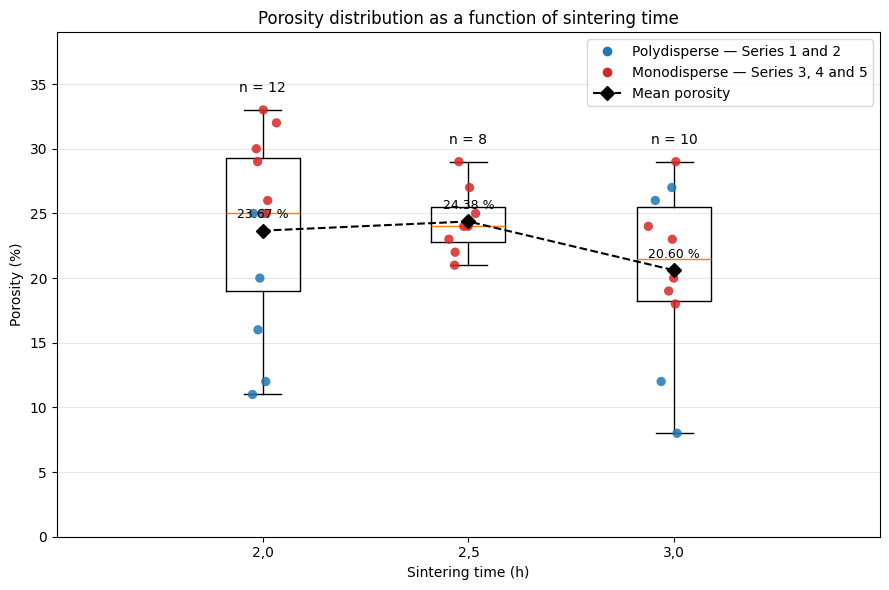

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import kruskal

# ============================================================
# 1. DATOS EXPERIMENTALES
# ============================================================
# La porosidad está introducida como fracción:
# 0.25 corresponde a 25 %.
#
# La columna "Broken" identifica los échantillons marcados
# en rojo en las tablas.
#
# En este análisis se incluyen todos los échantillons,
# incluidos los de la serie 3.

data = [
    # --------------------------------------------------------
    # Serie 1 - Sintering time = 2 h
    # --------------------------------------------------------
    ["1-A", 1, 2.0, 0.25, False],
    ["1-B", 1, 2.0, 0.12, False],
    ["1-C", 1, 2.0, 0.20, False],
    ["1-D", 1, 2.0, 0.25, True],
    ["1-E", 1, 2.0, 0.16, False],
    ["1-F", 1, 2.0, 0.11, False],

    # --------------------------------------------------------
    # Serie 2 - Sintering time = 3 h
    # --------------------------------------------------------
    ["2-A", 2, 3.0, 0.26, False],
    ["2-B", 2, 3.0, 0.27, False],
    ["2-C", 2, 3.0, 0.12, False],
    ["2-D", 2, 3.0, 0.08, False],

    # --------------------------------------------------------
    # Serie 3 - Sintering time = 3 h
    # --------------------------------------------------------
    ["3-A", 3, 3.0, 0.29, True],
    ["3-B", 3, 3.0, 0.23, True],
    ["3-C", 3, 3.0, 0.24, True],
    ["3-D", 3, 3.0, 0.19, True],
    ["3-E", 3, 3.0, 0.20, True],
    ["3-F", 3, 3.0, 0.18, True],

    # --------------------------------------------------------
    # Serie 4 - Sintering time = 2 h
    # --------------------------------------------------------
    ["4-A", 4, 2.0, 0.33, False],
    ["4-B", 4, 2.0, 0.32, True],
    ["4-C", 4, 2.0, 0.29, False],
    ["4-D", 4, 2.0, 0.30, False],
    ["4-E", 4, 2.0, 0.26, False],
    ["4-F", 4, 2.0, 0.25, True],

    # --------------------------------------------------------
    # Serie 5 - Sintering time = 2.5 h
    # --------------------------------------------------------
    ["5-A", 5, 2.5, 0.27, False],
    ["5-B", 5, 2.5, 0.29, False],
    ["5-C", 5, 2.5, 0.24, False],
    ["5-D", 5, 2.5, 0.25, True],
    ["5-E", 5, 2.5, 0.21, False],
    ["5-F", 5, 2.5, 0.24, True],
    ["5-G", 5, 2.5, 0.23, False],
    ["5-H", 5, 2.5, 0.22, False],
]

df = pd.DataFrame(
    data,
    columns=[
        "Sample",
        "Series",
        "Sintering time (h)",
        "Porosity",
        "Broken"
    ]
)

# Convertir la porosidad de fracción a porcentaje
df["Porosity (%)"] = 100 * df["Porosity"]


# ============================================================
# 2. SELECCIÓN DE LOS ÉCHANTILLONS
# ============================================================

# False: incluir todos los échantillons
# True: excluir los échantillons marcados en rojo
#
# Se deja en False para que la serie 3 aparezca en la gráfica.

EXCLUDE_BROKEN = False

if EXCLUDE_BROKEN:
    df_plot = df.loc[~df["Broken"]].copy()

    print("Broken samples excluded:")
    print(df.loc[df["Broken"], "Sample"].tolist())

else:
    df_plot = df.copy()
    print("All samples are included.")


# ============================================================
# 3. MOSTRAR LOS DATOS UTILIZADOS
# ============================================================

print("\nData used in the analysis:")

display(
    df_plot[
        [
            "Sample",
            "Series",
            "Sintering time (h)",
            "Porosity (%)",
            "Broken"
        ]
    ]
)


# ============================================================
# 4. TABLA ESTADÍSTICA
# ============================================================

grouped = df_plot.groupby(
    "Sintering time (h)"
)["Porosity (%)"]

summary = grouped.agg(
    N="count",
    Mean="mean",
    Median="median",
    Standard_deviation="std",
    Minimum="min",
    Maximum="max"
)

summary["Q1"] = grouped.quantile(0.25)
summary["Q3"] = grouped.quantile(0.75)
summary["IQR"] = summary["Q3"] - summary["Q1"]

summary = summary[
    [
        "N",
        "Mean",
        "Median",
        "Standard_deviation",
        "Q1",
        "Q3",
        "IQR",
        "Minimum",
        "Maximum"
    ]
]

print("\nStatistical summary:")

display(summary.round(2))


# ============================================================
# 5. DIAGRAMA DE CAJAS Y BIGOTES
#    DIFERENCIANDO POLYDISPERSE Y MONODISPERSE
# ============================================================

from matplotlib.lines import Line2D

# Clasificación según la serie
df_plot["Material type"] = np.where(
    df_plot["Series"].isin([1, 2]),
    "Polydisperse",
    "Monodisperse"
)

# Colores elegidos
material_colors = {
    "Polydisperse": "tab:blue",
    "Monodisperse": "tab:red"
}

# Tiempos de sinterización disponibles
times = sorted(
    df_plot["Sintering time (h)"].unique()
)

# Valores de porosidad agrupados por tiempo para el boxplot
porosity_groups = [
    df_plot.loc[
        df_plot["Sintering time (h)"] == time,
        "Porosity (%)"
    ].to_numpy()
    for time in times
]

fig, ax = plt.subplots(figsize=(9, 6))


# ============================================================
# CAJAS Y BIGOTES
# ============================================================

ax.boxplot(
    porosity_groups,
    positions=times,
    widths=0.18,
    showfliers=False,
    patch_artist=False
)


# ============================================================
# PUNTOS EXPERIMENTALES
# ============================================================

rng = np.random.default_rng(7)

for time in times:

    # Datos correspondientes al tiempo considerado
    time_data = df_plot.loc[
        df_plot["Sintering time (h)"] == time
    ].copy()

    # Pequeño desplazamiento horizontal para evitar superposición
    jitter = rng.normal(
        loc=0,
        scale=0.025,
        size=len(time_data)
    )

    time_data["x_position"] = time + jitter

    # Dibujar por separado cada tipo de distribución
    for material_type in [
        "Polydisperse",
        "Monodisperse"
    ]:

        subset = time_data.loc[
            time_data["Material type"] == material_type
        ]

        ax.scatter(
            subset["x_position"],
            subset["Porosity (%)"],
            color=material_colors[material_type],
            s=45,
            alpha=0.85,
            edgecolors="none",
            zorder=3
        )


# ============================================================
# MEDIA DE CADA TIEMPO DE SINTERIZACIÓN
# ============================================================

means = [
    np.mean(values)
    for values in porosity_groups
]

ax.plot(
    times,
    means,
    marker="D",
    linestyle="--",
    linewidth=1.5,
    markersize=7,
    color="black",
    label="Mean porosity",
    zorder=4
)

# Valor numérico de cada media
for time, mean_value in zip(times, means):

    ax.annotate(
        f"{mean_value:.2f} %",
        xy=(time, mean_value),
        xytext=(0, 9),
        textcoords="offset points",
        horizontalalignment="center",
        fontsize=9,
        color="black"
    )


# ============================================================
# NÚMERO DE MUESTRAS
# ============================================================

maximum_value = max(
    np.max(values)
    for values in porosity_groups
)

for time, values in zip(times, porosity_groups):

    ax.text(
        time,
        np.max(values) + 1.4,
        f"n = {len(values)}",
        horizontalalignment="center",
        fontsize=10
    )


# ============================================================
# LEYENDA
# ============================================================

legend_elements = [
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="none",
        markerfacecolor=material_colors["Polydisperse"],
        markeredgecolor="none",
        markersize=7,
        label="Polydisperse — Series 1 and 2"
    ),

    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="none",
        markerfacecolor=material_colors["Monodisperse"],
        markeredgecolor="none",
        markersize=7,
        label="Monodisperse — Series 3, 4 and 5"
    ),

    Line2D(
        [0],
        [0],
        marker="D",
        linestyle="--",
        color="black",
        markersize=7,
        label="Mean porosity"
    )
]

ax.legend(
    handles=legend_elements,
    loc="upper right"
)


# ============================================================
# FORMATO GENERAL
# ============================================================

ax.set_xlabel(
    "Sintering time (h)"
)

ax.set_ylabel(
    "Porosity (%)"
)

ax.set_title(
    "Porosity distribution as a function of sintering time"
)

ax.set_xticks(times)

ax.set_xticklabels(
    [
        str(time).replace(".", ",")
        for time in times
    ]
)

ax.set_ylim(
    0,
    maximum_value + 6
)

ax.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "porosity_vs_sintering_time_material_type.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

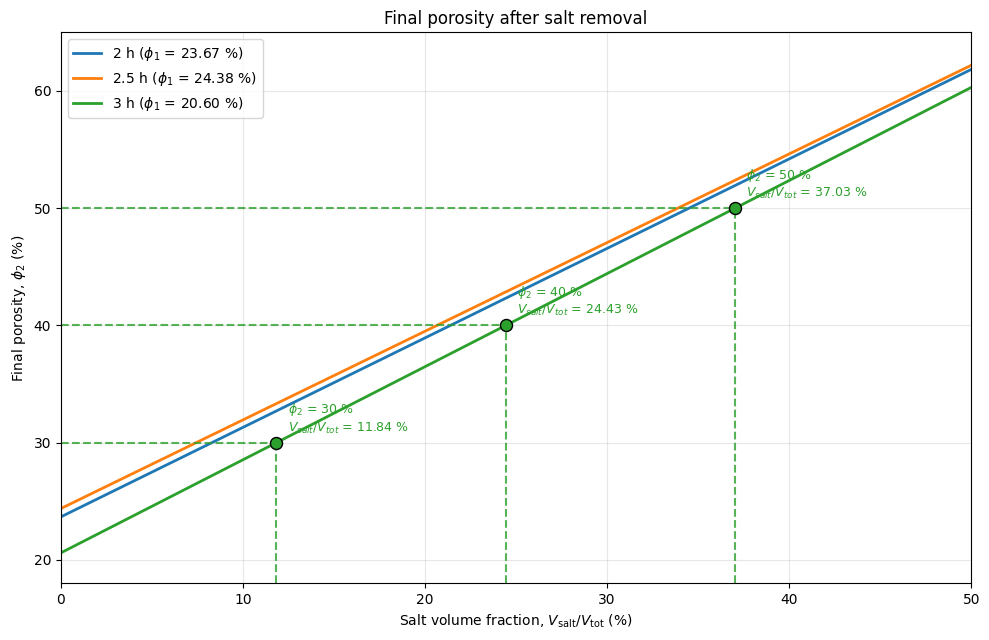

,Sintering time (h),Initial porosity phi_1 (%),Target porosity phi_2 (%),Salt fraction V_salt/V_tot (%)
0,3.0,20.6,30.0,11.839
1,3.0,20.6,40.0,24.433
2,3.0,20.6,50.0,37.028


Total sample volume = 132.73 cm³
Glass density = 2467 kg/m³
Salt density = 2160 kg/m³


,Target phi_2 (%),V_salt/V_tot (%),Salt volume (cm³),Synthetic rock bulk volume (cm³),Solid glass volume (cm³),Initial void volume (cm³),Glass mass (g),Salt mass (g),Initial total mass (g),Salt mass percentage (%),Calculated phi_2 (%)
0,30.0,11.839,15.714,117.018,92.913,24.106,229.215,33.942,263.157,12.898,30.0
1,40.0,24.433,32.431,100.301,79.639,20.662,196.470,70.051,266.521,26.283,40.0
2,50.0,37.028,49.148,83.585,66.366,17.218,163.725,106.159,269.884,39.335,50.0


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 1. POROSIDADES INICIALES
# ============================================================

porosity_data = {
    2.0: 0.2367,
    2.5: 0.2438,
    3.0: 0.2060
}

# Tiempo seleccionado
target_sintering_time = 3.0

# Porosidad inicial correspondiente a 3 horas
phi_1_target = porosity_data[target_sintering_time]

# Porosidades finales objetivo
target_phi_2_values = np.array([
    0.30,
    0.40,
    0.50
])


# ============================================================
# 2. FRACCIONES DE SAL NECESARIAS
# ============================================================
#
# phi_2 = phi_1 + (1 - phi_1) * V_salt/V_tot
#
# Despejando:
#
# V_salt/V_tot = (phi_2 - phi_1)/(1 - phi_1)

target_salt_fractions = (
    (target_phi_2_values - phi_1_target)
    / (1.0 - phi_1_target)
)

# Comprobación física
if np.any(target_salt_fractions < 0):
    raise ValueError(
        "All target porosities must be greater than "
        "or equal to the initial porosity."
    )

if np.any(target_salt_fractions >= 1):
    raise ValueError(
        "The calculated salt fractions must be lower than 1."
    )


# ============================================================
# 3. CREACIÓN DE LAS CURVAS
# ============================================================

# Intervalo de fracción volumétrica de sal
salt_fraction = np.linspace(
    0.0,
    0.50,
    400
)

fig, ax = plt.subplots(figsize=(10, 6.5))

line_by_time = {}

for sintering_time, phi_1 in porosity_data.items():

    phi_2_curve = (
        phi_1
        + (1.0 - phi_1) * salt_fraction
    )

    line, = ax.plot(
        100 * salt_fraction,
        100 * phi_2_curve,
        linewidth=2,
        label=(
            f"{sintering_time:g} h "
            f"($\\phi_1$ = {100 * phi_1:.2f} %)"
        )
    )

    line_by_time[sintering_time] = line


# ============================================================
# 4. LÍNEAS PUNTEADAS PARA 30 %, 40 % Y 50 %
# ============================================================

# Color de la curva de 3 horas
target_color = line_by_time[
    target_sintering_time
].get_color()

# Límites antes de construir las líneas verticales
ax.set_xlim(0, 50)
ax.set_ylim(18, 65)

y_min = ax.get_ylim()[0]

for phi_2_target, salt_fraction_target in zip(
    target_phi_2_values,
    target_salt_fractions
):

    x_target = 100 * salt_fraction_target
    y_target = 100 * phi_2_target

    # Línea horizontal desde el eje y hasta la curva de 3 h
    ax.hlines(
        y=y_target,
        xmin=0,
        xmax=x_target,
        colors=target_color,
        linestyles="--",
        linewidth=1.5,
        alpha=0.8
    )

    # Línea vertical desde la parte inferior hasta la intersección
    ax.vlines(
        x=x_target,
        ymin=y_min,
        ymax=y_target,
        colors=target_color,
        linestyles="--",
        linewidth=1.5,
        alpha=0.8
    )

    # Punto de intersección
    ax.scatter(
        x_target,
        y_target,
        color=target_color,
        edgecolor="black",
        s=75,
        zorder=5
    )

    # Texto junto al punto
    ax.annotate(
        (
            f"$\\phi_2$ = {y_target:.0f} %\n"
            f"$V_{{salt}}/V_{{tot}}$ = "
            f"{x_target:.2f} %"
        ),
        xy=(x_target, y_target),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=9,
        color=target_color
    )


# ============================================================
# 5. FORMATO DE LA GRÁFICA
# ============================================================

ax.set_xlabel(
    r"Salt volume fraction, "
    r"$V_{\mathrm{salt}}/V_{\mathrm{tot}}$ (%)"
)

ax.set_ylabel(
    r"Final porosity, $\phi_2$ (%)"
)

ax.set_title(
    "Final porosity after salt removal"
)

ax.grid(
    alpha=0.3
)

ax.legend(
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    "porosity_targets_3h.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 6. TABLA DE FRACCIONES VOLUMÉTRICAS
# ============================================================

target_results = pd.DataFrame(
    {
        "Sintering time (h)": [
            target_sintering_time
        ] * len(target_phi_2_values),

        "Initial porosity phi_1 (%)": [
            100 * phi_1_target
        ] * len(target_phi_2_values),

        "Target porosity phi_2 (%)":
            100 * target_phi_2_values,

        "Salt fraction V_salt/V_tot (%)":
            100 * target_salt_fractions
    }
)

display(
    target_results.round(3)
)

# ============================================================
# CÁLCULO DE VOLÚMENES Y MASAS PARA 30 %, 40 % Y 50 %
# ============================================================

# Volumen total externo de la muestra
total_volume_cm3 = (np.pi / 4) * (6.5 ** 2) * 4

# Densidades
glass_density_kg_m3 = 2467.0
salt_density_kg_m3 = 2160.0

# Conversión:
# 1000 kg/m³ = 1 g/cm³
glass_density_g_cm3 = glass_density_kg_m3 / 1000.0
salt_density_g_cm3 = salt_density_kg_m3 / 1000.0

mass_results = []

for phi_2_target, salt_fraction_target in zip(
    target_phi_2_values,
    target_salt_fractions
):

    # Volumen de sal
    salt_volume_cm3 = (
        salt_fraction_target
        * total_volume_cm3
    )

    # Volumen aparente de la roca inicial
    synthetic_rock_bulk_volume_cm3 = (
        (1.0 - salt_fraction_target)
        * total_volume_cm3
    )

    # Volumen de poros iniciales de la roca
    initial_void_volume_cm3 = (
        phi_1_target
        * synthetic_rock_bulk_volume_cm3
    )

    # Volumen sólido real de vidrio
    glass_solid_volume_cm3 = (
        (1.0 - phi_1_target)
        * synthetic_rock_bulk_volume_cm3
    )

    # También equivale a:
    # glass_solid_volume_cm3 =
    # (1 - phi_2_target) * total_volume_cm3

    # Masas
    salt_mass_g = (
        salt_density_g_cm3
        * salt_volume_cm3
    )

    glass_mass_g = (
        glass_density_g_cm3
        * glass_solid_volume_cm3
    )

    total_initial_mass_g = (
        glass_mass_g
        + salt_mass_g
    )

    salt_mass_percentage = (
        100
        * salt_mass_g
        / total_initial_mass_g
    )

    # Comprobación de la porosidad final
    final_void_volume_cm3 = (
        initial_void_volume_cm3
        + salt_volume_cm3
    )

    calculated_phi_2 = (
        final_void_volume_cm3
        / total_volume_cm3
    )

    mass_results.append(
        {
            "Target phi_2 (%)":
                100 * phi_2_target,

            "V_salt/V_tot (%)":
                100 * salt_fraction_target,

            "Salt volume (cm³)":
                salt_volume_cm3,

            "Synthetic rock bulk volume (cm³)":
                synthetic_rock_bulk_volume_cm3,

            "Solid glass volume (cm³)":
                glass_solid_volume_cm3,

            "Initial void volume (cm³)":
                initial_void_volume_cm3,

            "Glass mass (g)":
                glass_mass_g,

            "Salt mass (g)":
                salt_mass_g,

            "Initial total mass (g)":
                total_initial_mass_g,

            "Salt mass percentage (%)":
                salt_mass_percentage,

            "Calculated phi_2 (%)":
                100 * calculated_phi_2
        }
    )

mass_results_df = pd.DataFrame(
    mass_results
)

print(
    f"Total sample volume = "
    f"{total_volume_cm3:.2f} cm³"
)

print(
    f"Glass density = "
    f"{glass_density_kg_m3:.0f} kg/m³"
)

print(
    f"Salt density = "
    f"{salt_density_kg_m3:.0f} kg/m³"
)

display(
    mass_results_df.round(3)
)